In [1]:
import pathlib
import imod

In [2]:
src_dir = pathlib.Path('~').expanduser().resolve() / 'data/vcl/dataset'

In [3]:
file_maatregel2 = imod.idf.open(src_dir / 'gvg_maatregel2_diff_ref_2016_2023_Heel Terschelling.idf')
file_maatregel3 = imod.idf.open(src_dir / 'gvg_maatregel3_diff_ref_2016_2023_Heel Terschelling.idf')
file_maatregel4 = imod.idf.open(src_dir / 'gvg_maatregel4_diff_ref_2016_2023_Heel Terschelling.idf')

In [4]:
file_maatregel2 = file_maatregel2.rio.write_crs("EPSG:28992")
file_maatregel4 = file_maatregel4.rio.write_crs("EPSG:28992")
file_maatregel4 = file_maatregel4.rio.write_crs("EPSG:28992")

imod.formats.rasterio.save(src_dir / 'gvg_maatregel2_diff_ref_2016_2023_Heel Terschelling.tif', file_maatregel2)
imod.formats.rasterio.save(src_dir / 'gvg_maatregel3_diff_ref_2016_2023_Heel Terschelling.tif', file_maatregel3)
imod.formats.rasterio.save(src_dir / 'gvg_maatregel4_diff_ref_2016_2023_Heel Terschelling.tif', file_maatregel4)

In [8]:
import numpy as np

In [10]:
data = np.load(src_dir / 'preprocessed-data.npy', allow_pickle=True).item()

In [17]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import (
    LightSource,
    LinearSegmentedColormap,
    ListedColormap,
    from_levels_and_colors,
)

cmap_dir = (
    pathlib.Path("~").expanduser().expanduser() / "data/vcl/dataset/Freatische GXG"
)
colors, levels = imod.visualize.read_imod_legend(cmap_dir / "residu_detail.leg")
cmap_GXG, norm_GXG = from_levels_and_colors(levels, colors, extend="both")

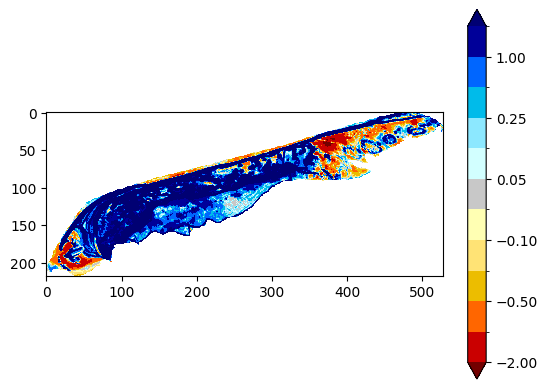

In [29]:
fig, ax = plt.subplots()
im = ax.imshow(data['2023']['GVGmaatregel_2'], cmap=cmap_GXG, norm=norm_GXG)
plt.colorbar(im)

In [27]:
norm_GXG.vmax

2.0

In [31]:
np.nanmedian(data['2023']['GVGmaatregel_2'])

np.float32(0.8703617)